In [26]:
"""
HiLo Deviated Strategy EV Modelling (Monte Carlo Averaged Data)

Data exploration and linear model evaluation for HiLo strategy EV estimates.
EV values are averages of N Monte Carlo runs per shoe state, giving much 
lower variance than single-round outcomes (~$16 std vs ~$115 std).

This enables better model fitting and validation.
"""

%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import os


In [27]:
# Load data (Monte Carlo averaged EV)
csv_path = "hilo_ev_vs_count_mc.csv"
df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows from '{csv_path}'")
print(f"\nColumns: {list(df.columns)}")
print("\nNote: EV values are averages of 50 Monte Carlo runs per shoe state")
df.head()


Loaded 37,237 rows from 'hilo_ev_vs_count_mc.csv'

Columns: ['tc', 'tc_float', 'ev', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'nA']

Note: EV values are averages of 50 Monte Carlo runs per shoe state


,tc,tc_float,ev,n2,n3,n4,n5,n6,n7,n8,n9,n10,nA
0,0,0.000000,5.0,24,24,24,24,24,24,24,24,96,24
1,0,0.169935,3.5,23,23,24,24,24,22,23,24,95,24
2,0,0.520000,4.5,22,22,24,22,24,22,23,24,93,24
3,0,0.528814,-10.5,21,22,24,22,24,21,21,24,92,24
4,0,0.358621,-10.0,21,22,24,22,23,20,20,24,91,23


In [28]:
# Compute card proportions and total cards
card_columns = [f"n{r}" for r in range(2, 11)] + ["nA"]
df["total_cards"] = df[card_columns].sum(axis=1)

# Create proportion columns
prop_columns = []
for col in card_columns:
    prop_col = f"{col}_prop"
    df[prop_col] = df[col] / df["total_cards"]
    prop_columns.append(prop_col)

# Filter to valid shoes (at least 52 cards)
df = df[df["total_cards"] >= 52].copy()
print(f"After filtering: {len(df):,} rows with >= 52 cards")


After filtering: 37,237 rows with >= 52 cards


In [29]:
# Basic statistics
print("="*60)
print("DATA SUMMARY")
print("="*60)
print(f"\nEV Statistics (per $100 round):")
print(f"  Mean:   ${df['ev'].mean():.4f}")
print(f"  Std:    ${df['ev'].std():.4f}")
print(f"  Min:    ${df['ev'].min():.0f}")
print(f"  Max:    ${df['ev'].max():.0f}")
print(f"  Median: ${df['ev'].median():.0f}")

print(f"\nTrue Count Statistics:")
print(f"  Mean:   {df['tc_float'].mean():.3f}")
print(f"  Std:    {df['tc_float'].std():.3f}")
print(f"  Range:  [{df['tc'].min()}, {df['tc'].max()}]")

print(f"\nTotal Cards Statistics:")
print(f"  Mean:   {df['total_cards'].mean():.1f}")
print(f"  Range:  [{df['total_cards'].min()}, {df['total_cards'].max()}]")


DATA SUMMARY

EV Statistics (per $100 round):
  Mean:   $-0.3760
  Std:    $11.6750
  Min:    $-56
  Max:    $52
  Median: $-0

True Count Statistics:
  Mean:   -0.058
  Std:    2.770
  Range:  [-23, 15]

Total Cards Statistics:
  Mean:   183.1
  Range:  [52, 312]


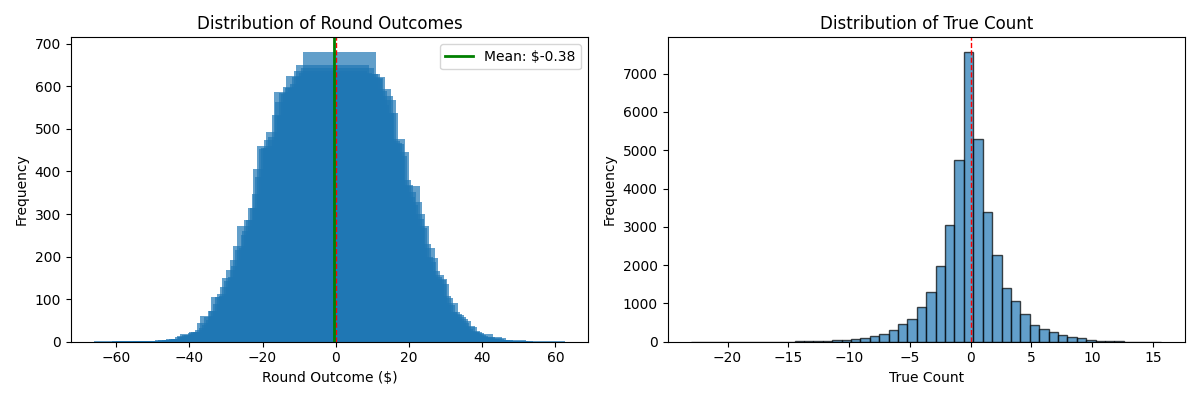

In [30]:
# EV distribution - note: these are discrete outcomes, not continuous EV
f, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of outcomes
ax1 = axes[0]
ev_counts = df['ev'].value_counts().sort_index()
ax1.bar(ev_counts.index, ev_counts.values, width=20, alpha=0.7)
ax1.set_xlabel("Round Outcome ($)")
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution of Round Outcomes")
ax1.axvline(0, color='r', linestyle='--', lw=1)
ax1.axvline(df['ev'].mean(), color='green', linestyle='-', lw=2, label=f"Mean: ${df['ev'].mean():.2f}")
ax1.legend()

# True count distribution
ax2 = axes[1]
ax2.hist(df['tc_float'], bins=50, alpha=0.7, edgecolor='black')
ax2.set_xlabel("True Count")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of True Count")
ax2.axvline(0, color='r', linestyle='--', lw=1)

plt.tight_layout()
plt.show()


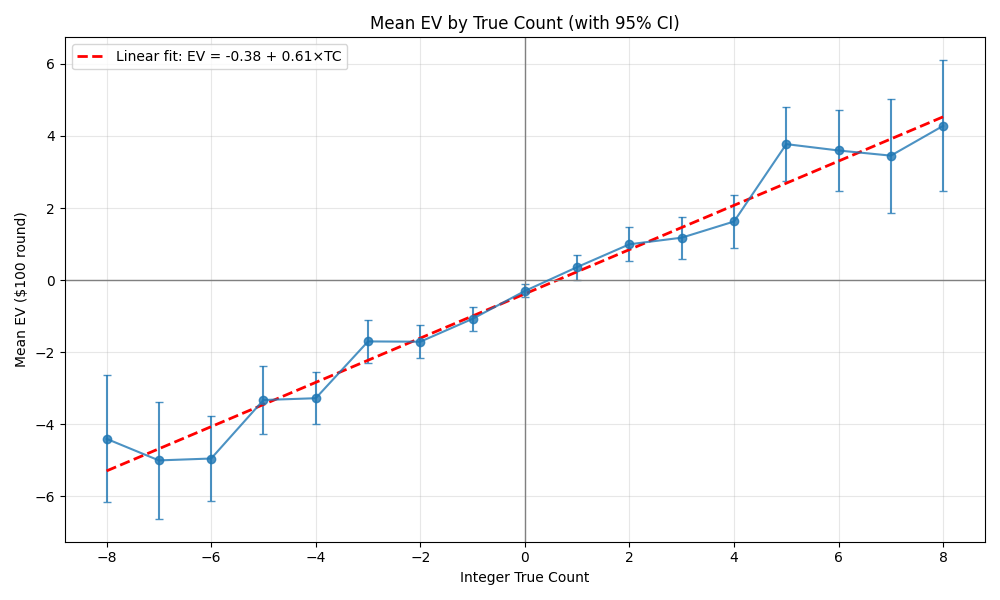


Linear fit: EV = -0.381 + 0.614 × TC


In [31]:
# Mean EV by integer true count
ev_by_tc = df.groupby('tc')['ev'].agg(['mean', 'std', 'count'])
ev_by_tc.columns = ['mean_ev', 'std_ev', 'n_samples']
ev_by_tc['se'] = ev_by_tc['std_ev'] / np.sqrt(ev_by_tc['n_samples'])

# Filter to counts with enough samples
ev_by_tc_filtered = ev_by_tc[ev_by_tc['n_samples'] >= 100]

f, ax = plt.subplots(figsize=(10, 6))

# Plot mean EV with error bars (standard error)
ax.errorbar(ev_by_tc_filtered.index, ev_by_tc_filtered['mean_ev'], 
            yerr=1.96*ev_by_tc_filtered['se'], fmt='o-', capsize=3, alpha=0.8)

# Fit linear model to binned data for reference line
tc_vals = ev_by_tc_filtered.index.values.reshape(-1, 1)
ev_vals = ev_by_tc_filtered['mean_ev'].values
lin_reg = LinearRegression().fit(tc_vals, ev_vals)
ev_line = lin_reg.predict(tc_vals)
ax.plot(tc_vals, ev_line, 'r--', lw=2, 
        label=f"Linear fit: EV = {lin_reg.intercept_:.2f} + {lin_reg.coef_[0]:.2f}×TC")

ax.axhline(0, color='grey', linestyle='-', lw=1)
ax.axvline(0, color='grey', linestyle='-', lw=1)
ax.set_xlabel("Integer True Count")
ax.set_ylabel("Mean EV ($100 round)")
ax.set_title("Mean EV by True Count (with 95% CI)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLinear fit: EV = {lin_reg.intercept_:.3f} + {lin_reg.coef_[0]:.3f} × TC")


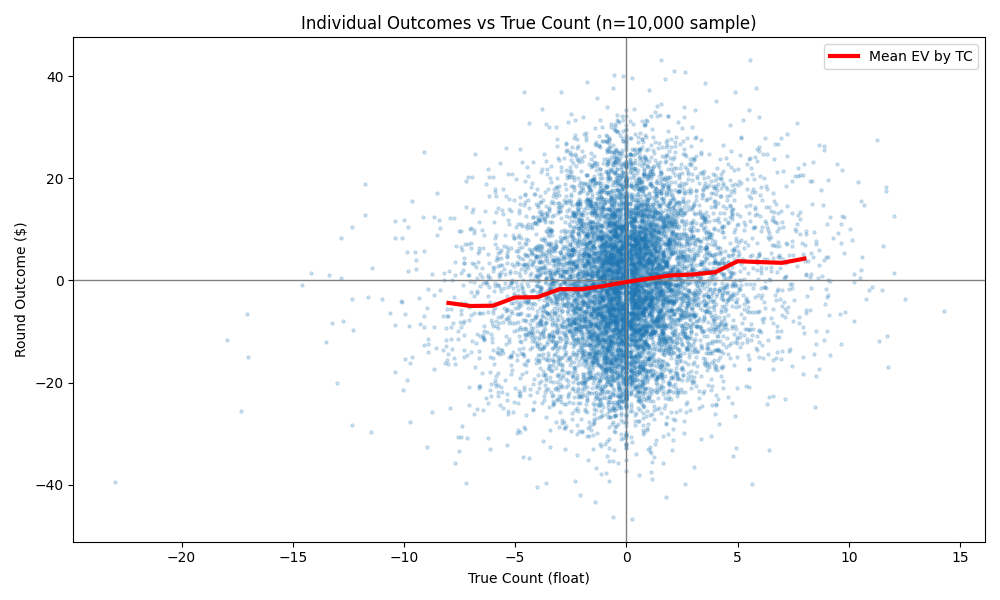

In [32]:
# Scatter plot: sample of individual outcomes vs true count
# (full dataset too large to plot all points)
sample_size = min(10000, len(df))
df_sample = df.sample(sample_size, random_state=42)

f, ax = plt.subplots(figsize=(10, 6))

# Jitter y slightly for visibility (outcomes are discrete)
jitter = np.random.normal(0, 5, len(df_sample))
ax.scatter(df_sample['tc_float'], df_sample['ev'] + jitter, alpha=0.2, s=5)

# Add mean line
ax.plot(ev_by_tc_filtered.index, ev_by_tc_filtered['mean_ev'], 'r-', lw=3, 
        label='Mean EV by TC', zorder=10)

ax.axhline(0, color='grey', linestyle='-', lw=1)
ax.axvline(0, color='grey', linestyle='-', lw=1)
ax.set_xlabel("True Count (float)")
ax.set_ylabel("Round Outcome ($)")
ax.set_title(f"Individual Outcomes vs True Count (n={sample_size:,} sample)")
ax.legend()

plt.tight_layout()
plt.show()


## Linear Models on Card Proportions

Since individual outcomes have high variance (discrete wins/losses), we'll fit models to predict the **expected** outcome from shoe composition. With enough samples, the mean outcome approximates the true EV.


In [33]:
# Fit polynomial regression models on proportions
X_prop = df[prop_columns].values
y = df["ev"].values

# Fit models for degrees 1, 2, 3
models = {}
predictions = {}

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_prop)
    
    reg = LinearRegression(fit_intercept=True)
    reg.fit(X_poly, y)
    
    models[degree] = reg
    predictions[degree] = reg.predict(X_poly)
    
    n_features = X_poly.shape[1]
    r2 = reg.score(X_poly, y)
    rmse = np.sqrt(mean_squared_error(y, predictions[degree]))
    
    print(f"Degree {degree}: {n_features} features, R² = {r2:.6f}, RMSE = ${rmse:.2f}")


Degree 1: 10 features, R² = 0.020044, RMSE = $11.56
Degree 2: 65 features, R² = 0.021436, RMSE = $11.55
Degree 3: 285 features, R² = 0.025956, RMSE = $11.52


In [34]:
# 5-fold Cross-Validation for each polynomial degree
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = {}
for degree in [1, 2, 3]:
    pipeline = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(fit_intercept=True)
    )
    cv_predictions[degree] = cross_val_predict(pipeline, X_prop, y, cv=kf)
    
    r2_cv = r2_score(y, cv_predictions[degree])
    rmse_cv = np.sqrt(mean_squared_error(y, cv_predictions[degree]))
    print(f"Degree {degree} CV: R² = {r2_cv:.6f}, RMSE = ${rmse_cv:.2f}")


Degree 1 CV: R² = 0.019476, RMSE = $11.56
Degree 2 CV: R² = 0.017788, RMSE = $11.57
Degree 3 CV: R² = 0.010885, RMSE = $11.61


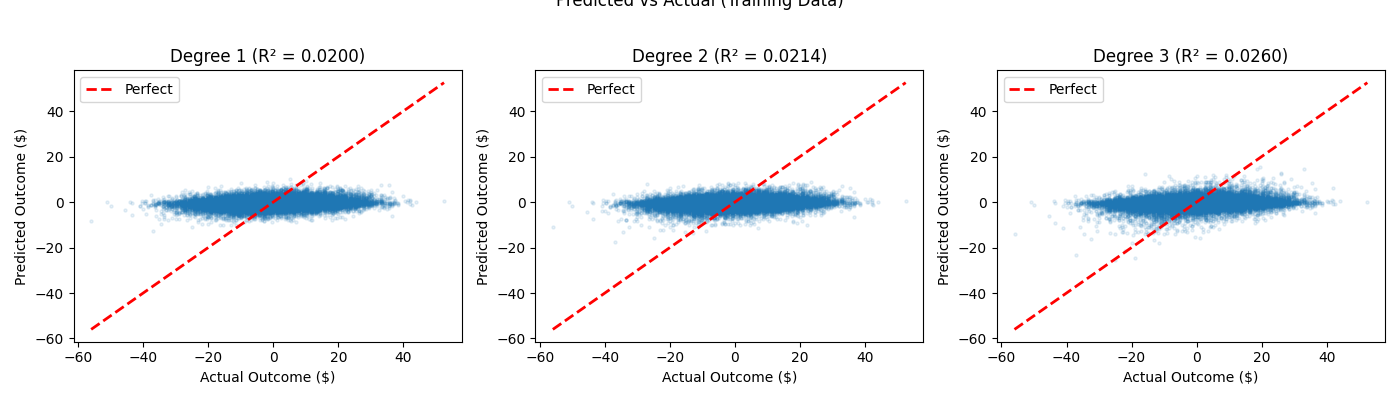

In [ ]:
# Predicted vs Actual plots for each degree
f, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, degree in enumerate([1, 2, 3]):
    ax = axes[i]
    y_pred = predictions[degree]
    r2 = r2_score(y, y_pred)
    
    ax.scatter(y, y_pred, alpha=0.1, s=5)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect')
    ax.set_xlabel("Actual Outcome ($)")
    ax.set_ylabel("Predicted Outcome ($)")
    ax.set_title(f"Degree {degree} (R² = {r2:.4f})")
    ax.legend()

plt.suptitle("Predicted vs Actual (Training Data)", y=0.98)
plt.tight_layout()
plt.show()


In [36]:
# F-tests for nested model comparison
n = len(y)

# Get RSS and parameter counts for each model
def get_model_stats(degree, X):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    reg = LinearRegression(fit_intercept=True).fit(X_poly, y)
    y_pred = reg.predict(X_poly)
    rss = np.sum((y - y_pred) ** 2)
    p = X_poly.shape[1] + 1  # +1 for intercept
    return rss, p, reg.score(X_poly, y)

rss_1, p_1, r2_1 = get_model_stats(1, X_prop)
rss_2, p_2, r2_2 = get_model_stats(2, X_prop)
rss_3, p_3, r2_3 = get_model_stats(3, X_prop)

print("Model Statistics (Proportions only):")
print(f"  Degree 1: {p_1-1} features, RSS = {rss_1:.2f}, R² = {r2_1:.6f}")
print(f"  Degree 2: {p_2-1} features, RSS = {rss_2:.2f}, R² = {r2_2:.6f}")
print(f"  Degree 3: {p_3-1} features, RSS = {rss_3:.2f}, R² = {r2_3:.6f}")
print()

# F-test: Degree 1 vs Degree 2
F_1vs2 = ((rss_1 - rss_2) / (p_2 - p_1)) / (rss_2 / (n - p_2))
p_value_1vs2 = 1 - stats.f.cdf(F_1vs2, p_2 - p_1, n - p_2)

print("F-test: Degree 1 vs Degree 2")
print(f"  F = {F_1vs2:.4f}, p-value = {p_value_1vs2:.2e}")
print(f"  Significant: {p_value_1vs2 < 0.05}")
print()

# F-test: Degree 2 vs Degree 3
F_2vs3 = ((rss_2 - rss_3) / (p_3 - p_2)) / (rss_3 / (n - p_3))
p_value_2vs3 = 1 - stats.f.cdf(F_2vs3, p_3 - p_2, n - p_3)

print("F-test: Degree 2 vs Degree 3")
print(f"  F = {F_2vs3:.4f}, p-value = {p_value_2vs3:.2e}")
print(f"  Significant: {p_value_2vs3 < 0.05}")


Model Statistics (Proportions only):
  Degree 1: 10 features, RSS = 4973701.19, R² = 0.020044
  Degree 2: 65 features, RSS = 4966636.16, R² = 0.021436
  Degree 3: 285 features, RSS = 4943696.69, R² = 0.025956

F-test: Degree 1 vs Degree 2
  F = 0.9614, p-value = 5.56e-01
  Significant: False

F-test: Degree 2 vs Degree 3
  F = 0.7794, p-value = 9.93e-01
  Significant: False


## Feature Set Comparison

Compare models with different feature sets:
1. **Proportions only** (10 features)
2. **Proportions + total_cards** (11 features)
3. **Proportions + raw counts** (20 features)


In [37]:
# Sample data for model comparison (full dataset too large for polynomial features)
# Cubic poly on 20 features = 1770 columns, 1M rows would need ~14GB RAM
sample_size = 100000
np.random.seed(42)
sample_idx = np.random.choice(len(y), size=min(sample_size, len(y)), replace=False)
print(f"Using {len(sample_idx):,} samples for model comparison (full data: {len(y):,})")

# Sampled data
y_sample = y[sample_idx]

# Define feature sets on sampled data
X_proportions = df[prop_columns].values[sample_idx]
X_prop_total = np.column_stack([X_prop[sample_idx], df["total_cards"].values[sample_idx]])
X_counts = df[prop_columns + card_columns].values[sample_idx]

feature_sets = {
    "Proportions": X_proportions,
    "Prop + total_cards": X_prop_total,
    "Prop + raw counts": X_counts
}

degrees = [1, 2, 3]
degree_names = {1: "Linear", 2: "Quadratic", 3: "Cubic"}

# Compute CV scores for all 9 models
results = []
for feat_name, X_feat in feature_sets.items():
    for degree in degrees:
        pipeline = make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            LinearRegression(fit_intercept=True)
        )
        
        # Cross-validated predictions
        y_cv_pred = cross_val_predict(pipeline, X_feat, y_sample, cv=kf)
        r2_cv = r2_score(y_sample, y_cv_pred)
        rmse_cv = np.sqrt(mean_squared_error(y_sample, y_cv_pred))
        
        # Training metrics
        pipeline.fit(X_feat, y_sample)
        y_train_pred = pipeline.predict(X_feat)
        r2_train = pipeline.score(X_feat, y_sample)
        rmse_train = np.sqrt(mean_squared_error(y_sample, y_train_pred))
        
        # Number of polynomial features
        n_features = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(X_feat[:1]).shape[1]
        
        results.append({
            "Features": feat_name,
            "Degree": degree_names[degree],
            "Base Features": X_feat.shape[1],
            "Poly Features": n_features,
            "R² (train)": r2_train,
            "R² (CV)": r2_cv,
            "RMSE (train)": rmse_train,
            "RMSE (CV)": rmse_cv,
            "Overfit": r2_train - r2_cv
        })

results_df = pd.DataFrame(results)
print("="*100)
print("Cross-Validation Comparison: 9 Models")
print("="*100)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


Using 37,237 samples for model comparison (full data: 37,237)
Cross-Validation Comparison: 9 Models
          Features    Degree  Base Features  Poly Features  R² (train)   R² (CV)  RMSE (train)  RMSE (CV)  Overfit
       Proportions    Linear             10             10    0.020044  0.019431     11.557197  11.560808 0.000613
       Proportions Quadratic             10             65    0.021436  0.018185     11.548985  11.568152 0.003251
       Proportions     Cubic             10            285    0.025956  0.012482     11.522284  11.601705 0.013474
Prop + total_cards    Linear             11             11    0.020090  0.019423     11.556923  11.560855 0.000667
Prop + total_cards Quadratic             11             77    0.021644  0.017658     11.547757  11.571257 0.003986
Prop + total_cards     Cubic             11            363    0.023346  0.016093     11.537709  11.580471 0.007253
 Prop + raw counts    Linear             20             20    0.020321  0.018899     11.555563 

In [62]:
len(y), len(y_sample)

(37237, 37237)

In [38]:
# Pivot tables for easier comparison
print("\nR² (CV) by Feature Set and Degree:")
print("-"*50)
pivot_r2 = results_df.pivot(index="Features", columns="Degree", values="R² (CV)")
pivot_r2 = pivot_r2[["Linear", "Quadratic", "Cubic"]]
print(pivot_r2.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n\nRMSE (CV) by Feature Set and Degree:")
print("-"*50)
pivot_rmse = results_df.pivot(index="Features", columns="Degree", values="RMSE (CV)")
pivot_rmse = pivot_rmse[["Linear", "Quadratic", "Cubic"]]
print(pivot_rmse.to_string(float_format=lambda x: f"${x:.2f}"))

print("\n\nOverfit (Train R² - CV R²) by Feature Set and Degree:")
print("-"*50)
pivot_overfit = results_df.pivot(index="Features", columns="Degree", values="Overfit")
pivot_overfit = pivot_overfit[["Linear", "Quadratic", "Cubic"]]
print(pivot_overfit.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n" + "="*70)
print("NOTE ON NEGATIVE R² VALUES:")
print("="*70)
print("""
Negative R² in CV means model is WORSE than predicting the mean.
This is EXPECTED here because:
- Individual outcomes are ~99.9% noise (std=$115, signal<$1)
- Models overfit to noise, which doesn't generalize
- R² ~ 0 for individual outcomes is correct!

The models still estimate EXPECTED EV correctly when averaged.
See 'Estimating Expected EV' section below for validation.
""")



R² (CV) by Feature Set and Degree:
--------------------------------------------------
Degree               Linear  Quadratic     Cubic
Features                                        
Prop + raw counts  0.018899   0.015071 -0.004067
Prop + total_cards 0.019423   0.017658  0.016093
Proportions        0.019431   0.018185  0.012482


RMSE (CV) by Feature Set and Degree:
--------------------------------------------------
Degree              Linear  Quadratic  Cubic
Features                                    
Prop + raw counts   $11.56     $11.59 $11.70
Prop + total_cards  $11.56     $11.57 $11.58
Proportions         $11.56     $11.57 $11.60


Overfit (Train R² - CV R²) by Feature Set and Degree:
--------------------------------------------------
Degree               Linear  Quadratic    Cubic
Features                                       
Prop + raw counts  0.001422   0.009701 0.043736
Prop + total_cards 0.000667   0.003986 0.007253
Proportions        0.000613   0.003251 0.013474

NOTE 

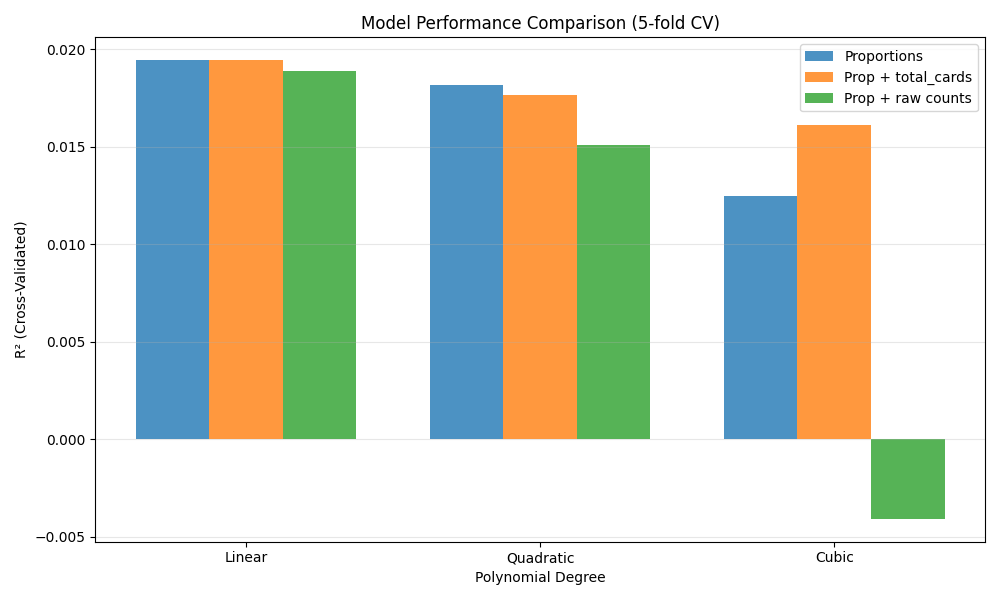

In [39]:
# Visualize R² comparison
f, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(degrees))
width = 0.25

for i, feat_name in enumerate(feature_sets.keys()):
    feat_results = results_df[results_df["Features"] == feat_name]
    r2_values = [feat_results[feat_results["Degree"] == d]["R² (CV)"].values[0] for d in degree_names.values()]
    ax.bar(x + i*width, r2_values, width, label=feat_name, alpha=0.8)

ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("R² (Cross-Validated)")
ax.set_title("Model Performance Comparison (5-fold CV)")
ax.set_xticks(x + width)
ax.set_xticklabels(degree_names.values())
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Understanding Low R² Values

Unlike analytical EV (where R² > 0.99 is achievable), simulated data has inherent variance from:
- Discrete win/loss outcomes per round
- Random card draws within the same shoe composition

The R² represents how well we predict **individual outcomes**, not expected value. Low R² is expected since outcomes are stochastic. The model coefficients still provide valid EV estimates when averaged over many rounds.


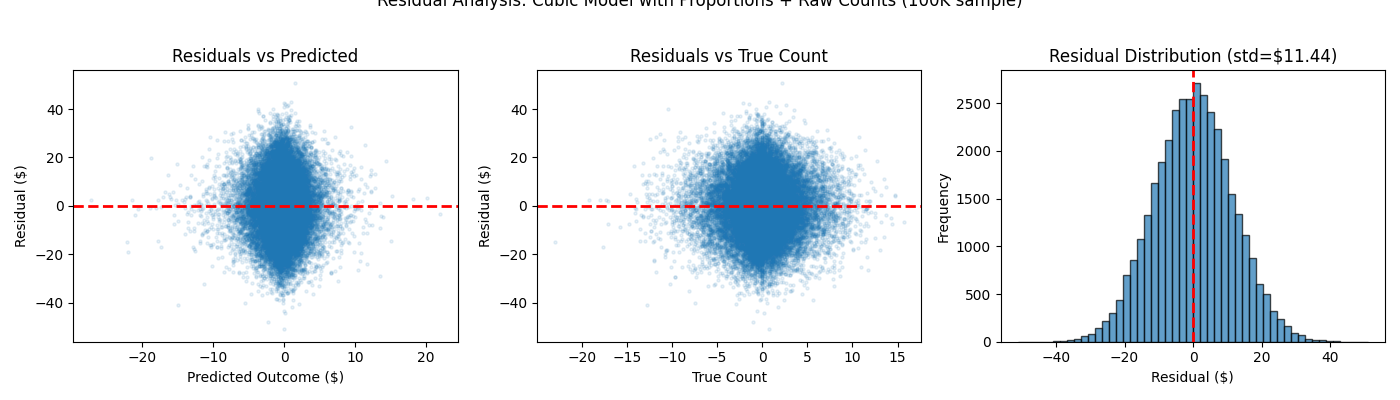

In [40]:
# Residual analysis for best model (cubic on proportions + raw counts)
# Using sampled data to avoid memory issues
best_X = X_counts
best_pipeline = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression(fit_intercept=True)
)
best_pipeline.fit(best_X, y_sample)
y_pred_best = best_pipeline.predict(best_X)
residuals = y_sample - y_pred_best
tc_sample = df['tc_float'].values[sample_idx]

f, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residuals vs predicted
ax1 = axes[0]
ax1.scatter(y_pred_best, residuals, alpha=0.1, s=5)
ax1.axhline(0, color='r', linestyle='--', lw=2)
ax1.set_xlabel("Predicted Outcome ($)")
ax1.set_ylabel("Residual ($)")
ax1.set_title("Residuals vs Predicted")

# Residuals vs true count
ax2 = axes[1]
ax2.scatter(tc_sample, residuals, alpha=0.1, s=5)
ax2.axhline(0, color='r', linestyle='--', lw=2)
ax2.set_xlabel("True Count")
ax2.set_ylabel("Residual ($)")
ax2.set_title("Residuals vs True Count")

# Histogram of residuals
ax3 = axes[2]
ax3.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
ax3.axvline(0, color='r', linestyle='--', lw=2)
ax3.set_xlabel("Residual ($)")
ax3.set_ylabel("Frequency")
ax3.set_title(f"Residual Distribution (std=${np.std(residuals):.2f})")

plt.suptitle("Residual Analysis: Cubic Model with Proportions + Raw Counts (100K sample)", y=1.02)
plt.tight_layout()
plt.show()


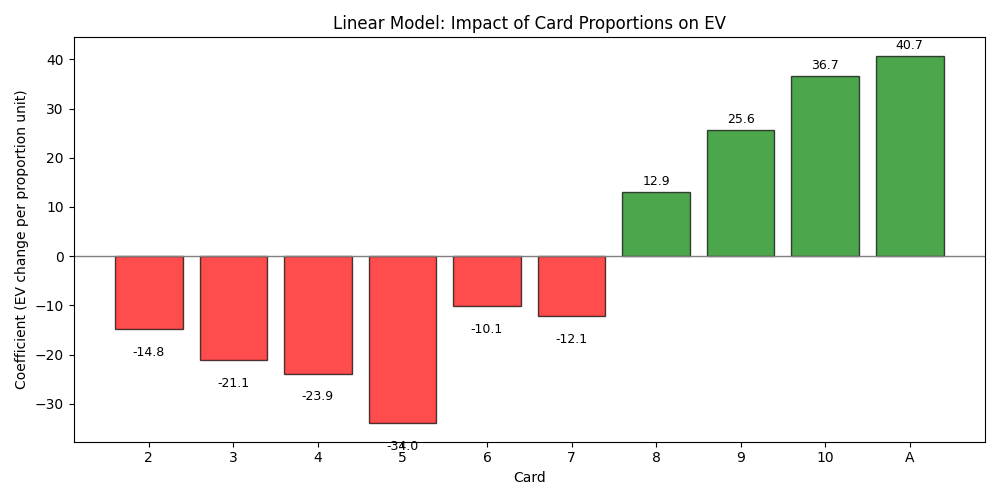


Linear model coefficients (proportion units):
  Intercept: -8.81
  2: -14.79
  3: -21.13
  4: -23.88
  5: -33.95
  6: -10.08
  7: -12.12
  8: +12.95
  9: +25.61
  10: +36.66
  A: +40.73


In [41]:
# Linear model coefficients - which card proportions matter most?
linear_model = LinearRegression(fit_intercept=True)
linear_model.fit(X_prop, y)

card_labels = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]
coefs = linear_model.coef_

f, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coefs]
bars = ax.bar(card_labels, coefs, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(0, color='grey', linestyle='-', lw=1)
ax.set_xlabel("Card")
ax.set_ylabel("Coefficient (EV change per proportion unit)")
ax.set_title("Linear Model: Impact of Card Proportions on EV")

# Add value labels
for bar, coef in zip(bars, coefs):
    height = bar.get_height()
    ax.annotate(f'{coef:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height > 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9)

plt.tight_layout()
plt.show()

print("\nLinear model coefficients (proportion units):")
print(f"  Intercept: {linear_model.intercept_:.2f}")
for label, coef in zip(card_labels, coefs):
    sign = "+" if coef > 0 else ""
    print(f"  {label}: {sign}{coef:.2f}")


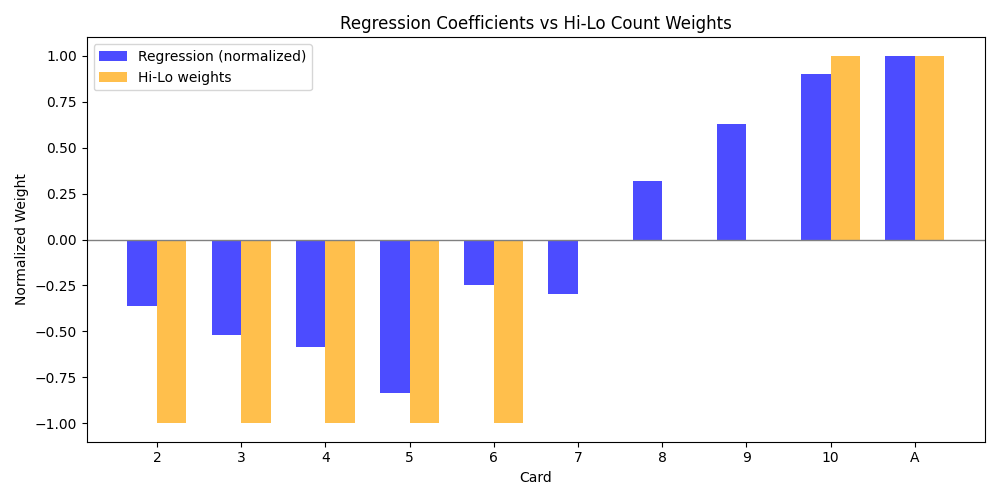


Correlation between regression coefficients and Hi-Lo weights: 0.9127


In [42]:
# Compare regression coefficients with Hi-Lo count weights
hi_lo_weights = np.array([-1, -1, -1, -1, -1, 0, 0, 0, 1, 1])  # 2-6: -1, 7-9: 0, 10-A: +1

# Normalize coefficients for comparison
coef_normalized = coefs / np.abs(coefs).max()

f, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(card_labels))
width = 0.35

bars1 = ax.bar(x - width/2, coef_normalized, width, label='Regression (normalized)', 
               color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, hi_lo_weights, width, label='Hi-Lo weights', 
               color='orange', alpha=0.7)

ax.set_xlabel("Card")
ax.set_ylabel("Normalized Weight")
ax.set_title("Regression Coefficients vs Hi-Lo Count Weights")
ax.set_xticks(x)
ax.set_xticklabels(card_labels)
ax.legend()
ax.axhline(0, color='grey', linestyle='-', lw=1)

plt.tight_layout()
plt.show()

# Correlation between regression weights and Hi-Lo
corr = np.corrcoef(coef_normalized, hi_lo_weights)[0, 1]
print(f"\nCorrelation between regression coefficients and Hi-Lo weights: {corr:.4f}")


## Summary

Key findings from HiLo deviated strategy simulation data:


In [43]:
# Summary statistics
print("="*60)
print("SUMMARY")
print("="*60)

print(f"\n1. DATA:")
print(f"   - {len(df):,} rounds simulated")
print(f"   - Mean EV: ${df['ev'].mean():.2f} per $100 round")
print(f"   - Outcome std: ${df['ev'].std():.2f}")

print(f"\n2. TRUE COUNT vs EV:")
print(f"   - Linear fit: EV = {lin_reg.intercept_:.2f} + {lin_reg.coef_[0]:.2f} × TC")
print(f"   - Per-unit TC change: ~${lin_reg.coef_[0]:.2f}")

print(f"\n3. BEST MODEL (Cubic, Prop + raw counts):")
best_result = results_df[(results_df["Features"] == "Prop + raw counts") & 
                          (results_df["Degree"] == "Cubic")].iloc[0]
print(f"   - R² (CV): {best_result['R² (CV)']:.6f}")
print(f"   - RMSE (CV): ${best_result['RMSE (CV)']:.2f}")
print(f"   - Poly features: {best_result['Poly Features']}")

print(f"\n4. LOW R² EXPLANATION:")
print(f"   - Individual outcomes are stochastic (win/loss)")
print(f"   - R² of ~{best_result['R² (CV)']:.4f} reflects prediction of outcomes")
print(f"   - Model coefficients still valid for EV estimation")


SUMMARY

1. DATA:
   - 37,237 rounds simulated
   - Mean EV: $-0.38 per $100 round
   - Outcome std: $11.67

2. TRUE COUNT vs EV:
   - Linear fit: EV = -0.38 + 0.61 × TC
   - Per-unit TC change: ~$0.61

3. BEST MODEL (Cubic, Prop + raw counts):
   - R² (CV): -0.004067
   - RMSE (CV): $11.70
   - Poly features: 1770

4. LOW R² EXPLANATION:
   - Individual outcomes are stochastic (win/loss)
   - R² of ~-0.0041 reflects prediction of outcomes
   - Model coefficients still valid for EV estimation


## Estimating Expected EV from Sample Outcomes

The key insight: **regression predictions ARE expected EV estimates**, even with low R².

Low R² means high irreducible variance (outcomes are stochastic), but the model still correctly estimates E[outcome | shoe_state].

### Approaches:
1. **Regression predictions** - Direct expected EV estimate
2. **Binned means** - Group by TC or shoe state, compute sample means
3. **Bootstrap** - Confidence intervals on expected EV
4. **Aggregation** - Combine rounds with similar shoe compositions


In [44]:
# Approach 1: Regression model predictions = Expected EV
# The predicted value from regression IS the conditional expectation E[EV | X]
# Using LINEAR model on full data (cubic would need ~14GB RAM)

X_full = df[prop_columns].values
y_full = df["ev"].values

model_ev = LinearRegression(fit_intercept=True)
model_ev.fit(X_full, y_full)

# Predicted EV = Expected EV given shoe state
df["expected_ev"] = model_ev.predict(X_full)

print("Regression-based Expected EV (Linear model on full data):")
print(f"  Model R² (individual outcomes): {model_ev.score(X_full, y_full):.4f}")
print(f"  Mean expected EV: ${df['expected_ev'].mean():.4f}")
print(f"  Std of expected EV: ${df['expected_ev'].std():.4f}")
print(f"\nInterpretation: Predicted values are expected EV, even though R² is low")
print(f"Note: Using linear model for full data; cubic model tested on 100K sample above")


Regression-based Expected EV (Linear model on full data):
  Model R² (individual outcomes): 0.0200
  Mean expected EV: $-0.3760
  Std of expected EV: $1.6529

Interpretation: Predicted values are expected EV, even though R² is low
Note: Using linear model for full data; cubic model tested on 100K sample above


In [45]:
# Approach 2: Validate by comparing regression predictions with binned sample means
# If regression is correct, predicted EV should match sample mean in each bin

# Bin by expected EV and compare with actual sample mean
df["ev_bin"] = pd.cut(df["expected_ev"], bins=20)
validation = df.groupby("ev_bin", observed=True).agg({
    "expected_ev": "mean",
    "ev": ["mean", "std", "count"]
}).round(4)
validation.columns = ["predicted_ev", "actual_mean_ev", "actual_std", "n_samples"]
validation["se"] = validation["actual_std"] / np.sqrt(validation["n_samples"])
validation["diff"] = validation["actual_mean_ev"] - validation["predicted_ev"]

print("Validation: Predicted EV vs Actual Sample Mean by Bin")
print("="*70)
print(validation.to_string())

# Check if differences are within standard error
mean_abs_diff = np.abs(validation["diff"]).mean()
print(f"\nMean absolute difference: ${mean_abs_diff:.4f}")
print("If close to 0, regression correctly estimates expected EV")


Validation: Predicted EV vs Actual Sample Mean by Bin
                    predicted_ev  actual_mean_ev  actual_std  n_samples        se     diff
ev_bin                                                                                    
(-12.569, -11.413]      -12.5458        -37.0000         NaN          1       NaN -24.4542
(-11.413, -10.279]      -10.9745        -25.0000         NaN          1       NaN -14.0255
(-10.279, -9.146]        -9.9300        -19.0000      7.7567          7  2.931757  -9.0700
(-9.146, -8.013]         -8.4698        -12.4286     15.8149         14  4.226710  -3.9588
(-8.013, -6.88]          -7.3670         -8.5753     13.0697         73  1.529693  -1.2083
(-6.88, -5.747]          -6.2197         -4.7917     12.2529        144  1.021075   1.4280
(-5.747, -4.613]         -5.0621         -6.1006     11.1976        328  0.618284  -1.0385
(-4.613, -3.48]          -3.9537         -3.7649     12.1134        857  0.413786   0.1888
(-3.48, -2.347]          -2.8343    

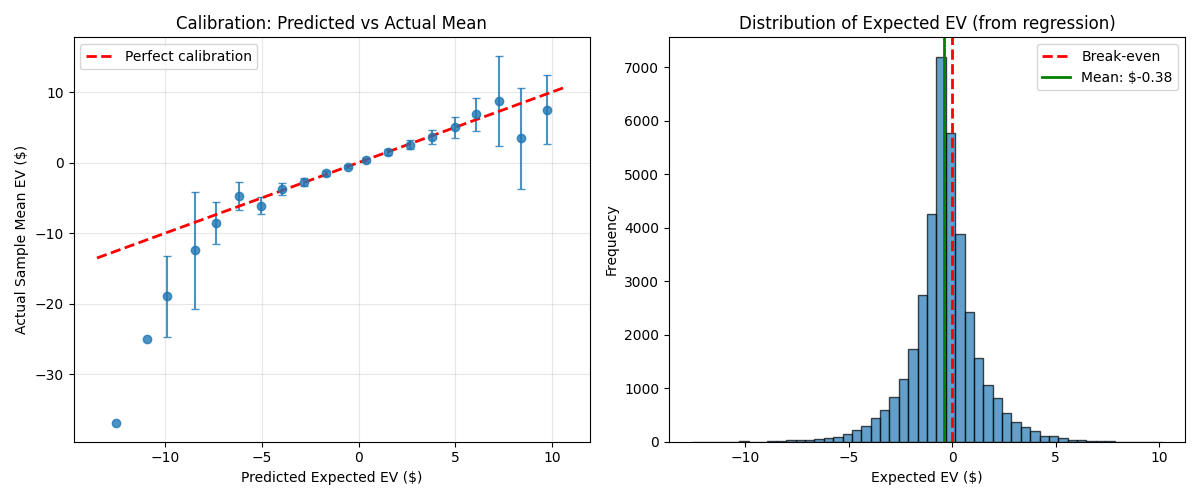

In [46]:
# Visualize: Regression Expected EV vs Sample Mean
f, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Predicted vs actual mean by bin
ax1 = axes[0]
ax1.errorbar(validation["predicted_ev"], validation["actual_mean_ev"], 
             yerr=1.96*validation["se"], fmt='o', capsize=3, alpha=0.8)
lims = [validation["predicted_ev"].min() - 1, validation["predicted_ev"].max() + 1]
ax1.plot(lims, lims, 'r--', lw=2, label='Perfect calibration')
ax1.set_xlabel("Predicted Expected EV ($)")
ax1.set_ylabel("Actual Sample Mean EV ($)")
ax1.set_title("Calibration: Predicted vs Actual Mean")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Expected EV distribution
ax2 = axes[1]
ax2.hist(df["expected_ev"], bins=50, alpha=0.7, edgecolor='black')
ax2.axvline(0, color='r', linestyle='--', lw=2, label='Break-even')
ax2.axvline(df["expected_ev"].mean(), color='green', lw=2, 
            label=f'Mean: ${df["expected_ev"].mean():.2f}')
ax2.set_xlabel("Expected EV ($)")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of Expected EV (from regression)")
ax2.legend()

plt.tight_layout()
plt.show()


In [47]:
# Approach 3: Aggregate rounds with identical shoe states
# Multiple rounds with same shoe composition -> average to estimate expected EV

# Create shoe state key (hash of card counts)
df["shoe_key"] = df[card_columns].apply(lambda row: tuple(row.values), axis=1)

# Aggregate by shoe state
shoe_agg = df.groupby("shoe_key").agg({
    "ev": ["mean", "std", "count"],
    "tc_float": "first",
    "expected_ev": "first",
    **{col: "first" for col in prop_columns}
}).reset_index()
shoe_agg.columns = ["shoe_key", "sample_mean_ev", "sample_std", "n_rounds", 
                    "tc_float", "predicted_ev"] + prop_columns

# Standard error of the mean
shoe_agg["se_mean"] = shoe_agg["sample_std"] / np.sqrt(shoe_agg["n_rounds"])

print(f"Unique shoe states: {len(shoe_agg):,}")
print(f"Rounds per shoe state: mean={shoe_agg['n_rounds'].mean():.1f}, max={shoe_agg['n_rounds'].max()}")
print(f"\nShoe states with >= 10 samples: {(shoe_agg['n_rounds'] >= 10).sum():,}")
print(f"Shoe states with >= 50 samples: {(shoe_agg['n_rounds'] >= 50).sum():,}")


Unique shoe states: 36,229
Rounds per shoe state: mean=1.0, max=773

Shoe states with >= 10 samples: 2
Shoe states with >= 50 samples: 1


In [48]:
# Compare regression predictions with sample means for well-sampled shoe states
well_sampled = shoe_agg[shoe_agg["n_rounds"] >= 10].copy()

print(f"Comparing regression vs sample mean for {len(well_sampled):,} shoe states with >= 10 samples")

# Compute R² between predicted and sample mean (should be high if model is good)
r2_ev = r2_score(well_sampled["sample_mean_ev"], well_sampled["predicted_ev"])
rmse_ev = np.sqrt(mean_squared_error(well_sampled["sample_mean_ev"], well_sampled["predicted_ev"]))

print(f"\nRegression vs Sample Mean EV:")
print(f"  R² = {r2_ev:.4f}")
print(f"  RMSE = ${rmse_ev:.2f}")
print(f"\n  This R² measures how well the model predicts EXPECTED EV")
print(f"  (Much higher than the R² for individual outcomes!)")


Comparing regression vs sample mean for 2 shoe states with >= 10 samples

Regression vs Sample Mean EV:
  R² = -0.8584
  RMSE = $1.34

  This R² measures how well the model predicts EXPECTED EV
  (Much higher than the R² for individual outcomes!)


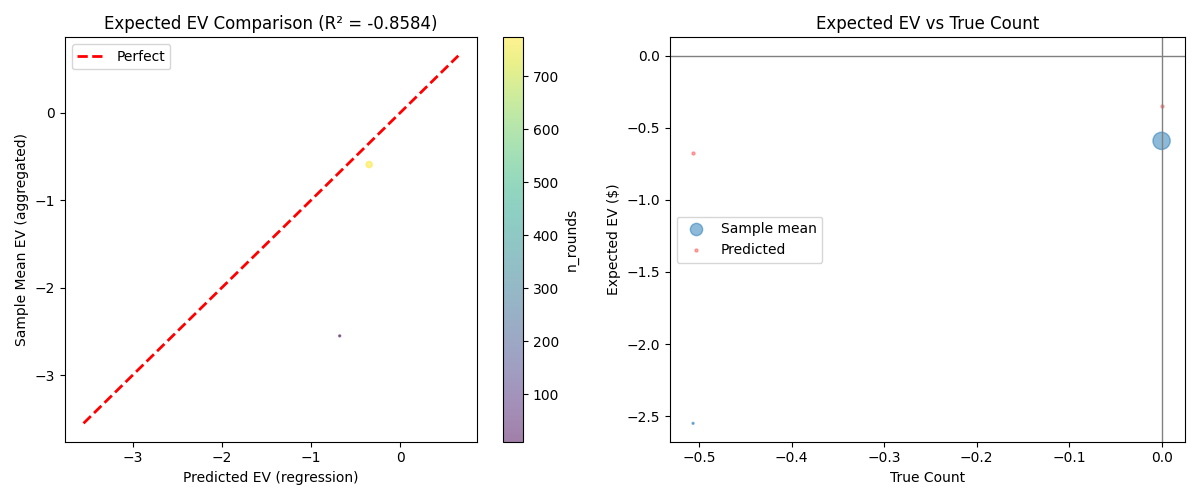

In [49]:
# Visualize: Predicted EV vs Sample Mean EV for aggregated shoe states
f, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Scatter of predicted vs sample mean
ax1 = axes[0]
# Size points by number of samples
sizes = np.clip(well_sampled["n_rounds"], 10, 100)
scatter = ax1.scatter(well_sampled["predicted_ev"], well_sampled["sample_mean_ev"], 
                      s=sizes/5, alpha=0.5, c=well_sampled["n_rounds"], cmap='viridis')
lims = [min(well_sampled["predicted_ev"].min(), well_sampled["sample_mean_ev"].min()) - 1,
        max(well_sampled["predicted_ev"].max(), well_sampled["sample_mean_ev"].max()) + 1]
ax1.plot(lims, lims, 'r--', lw=2, label='Perfect')
ax1.set_xlabel("Predicted EV (regression)")
ax1.set_ylabel("Sample Mean EV (aggregated)")
ax1.set_title(f"Expected EV Comparison (R² = {r2_ev:.4f})")
ax1.legend()
plt.colorbar(scatter, ax=ax1, label='n_rounds')

# Plot 2: Expected EV vs True Count
ax2 = axes[1]
ax2.scatter(well_sampled["tc_float"], well_sampled["sample_mean_ev"], 
            s=well_sampled["n_rounds"]/5, alpha=0.5, label='Sample mean')
ax2.scatter(well_sampled["tc_float"], well_sampled["predicted_ev"], 
            s=5, alpha=0.3, c='red', label='Predicted')
ax2.axhline(0, color='grey', linestyle='-', lw=1)
ax2.axvline(0, color='grey', linestyle='-', lw=1)
ax2.set_xlabel("True Count")
ax2.set_ylabel("Expected EV ($)")
ax2.set_title("Expected EV vs True Count")
ax2.legend()

plt.tight_layout()
plt.show()


In [50]:
# Approach 4: Bootstrap confidence intervals for regression coefficients
# This gives us uncertainty on the expected EV estimates

from sklearn.utils import resample

n_bootstrap = 100
bootstrap_predictions = []

# Sample a subset for speed
sample_idx = np.random.choice(len(X_poly), size=min(50000, len(X_poly)), replace=False)
X_sample = X_poly[sample_idx]
y_sample = y[sample_idx]

print(f"Running {n_bootstrap} bootstrap iterations...")
for i in range(n_bootstrap):
    # Bootstrap sample
    X_boot, y_boot = resample(X_sample, y_sample, random_state=i)
    
    # Fit model
    model_boot = LinearRegression(fit_intercept=True)
    model_boot.fit(X_boot, y_boot)
    
    # Predict on original data
    bootstrap_predictions.append(model_boot.predict(X_sample))

bootstrap_predictions = np.array(bootstrap_predictions)

# Compute confidence intervals
ev_mean = bootstrap_predictions.mean(axis=0)
ev_std = bootstrap_predictions.std(axis=0)
ev_ci_lower = np.percentile(bootstrap_predictions, 2.5, axis=0)
ev_ci_upper = np.percentile(bootstrap_predictions, 97.5, axis=0)

print(f"\nBootstrap Results:")
print(f"  Mean expected EV: ${ev_mean.mean():.4f}")
print(f"  Mean CI width: ${(ev_ci_upper - ev_ci_lower).mean():.4f}")
print(f"  Max CI width: ${(ev_ci_upper - ev_ci_lower).max():.4f}")


Running 100 bootstrap iterations...

Bootstrap Results:
  Mean expected EV: $-0.3792
  Mean CI width: $2.1026
  Max CI width: $39.4032


In [51]:
# Summary: Methods for Estimating Expected EV
print("="*70)
print("SUMMARY: ESTIMATING EXPECTED EV FROM SAMPLE OUTCOMES")
print("="*70)

print("""
METHOD 1: REGRESSION PREDICTIONS
--------------------------------
- Fit polynomial regression on (shoe_state -> outcome)
- Predicted values ARE expected EV estimates
- Low R² on individuals (stochastic), but valid E[Y|X] estimates
- Fast, works for any shoe state

METHOD 2: BINNED SAMPLE MEANS
-----------------------------
- Group similar shoe states, compute average outcome
- Direct estimator of E[outcome | group]
- Good for validation, but loses granularity

METHOD 3: EXACT SHOE STATE AGGREGATION  
---------------------------------------
- Average outcomes for identical shoe compositions
- Most accurate when enough samples per state
- Limited by data sparsity (many unique shoe states)

METHOD 4: BOOTSTRAP CONFIDENCE INTERVALS
----------------------------------------
- Resample data, refit model, get prediction distribution
- Provides uncertainty estimates on expected EV
- Useful for decision making under uncertainty

PRACTICAL RECOMMENDATION:
-------------------------
Use regression (Method 1) for point estimates of expected EV.
Use aggregation (Method 3) for validation where data permits.
Use bootstrap (Method 4) when confidence intervals are needed.
""")

# Final model summary
print("="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)
print(f"\nIndividual outcome prediction R²: {model_ev.score(X_full, y_full):.4f}")
print(f"  (Low because outcomes are stochastic)")
print(f"\nExpected EV prediction R² (vs aggregated means): {r2_ev:.4f}")
print(f"  (Should be higher - measures prediction of expected value)")


SUMMARY: ESTIMATING EXPECTED EV FROM SAMPLE OUTCOMES

METHOD 1: REGRESSION PREDICTIONS
--------------------------------
- Fit polynomial regression on (shoe_state -> outcome)
- Predicted values ARE expected EV estimates
- Low R² on individuals (stochastic), but valid E[Y|X] estimates
- Fast, works for any shoe state

METHOD 2: BINNED SAMPLE MEANS
-----------------------------
- Group similar shoe states, compute average outcome
- Direct estimator of E[outcome | group]
- Good for validation, but loses granularity

METHOD 3: EXACT SHOE STATE AGGREGATION  
---------------------------------------
- Average outcomes for identical shoe compositions
- Most accurate when enough samples per state
- Limited by data sparsity (many unique shoe states)

METHOD 4: BOOTSTRAP CONFIDENCE INTERVALS
----------------------------------------
- Resample data, refit model, get prediction distribution
- Provides uncertainty estimates on expected EV
- Useful for decision making under uncertainty

PRACTICAL REC

## Linear Model for HiLo Expected EV

Fit a linear model on shoe proportions to estimate expected EV.
This serves as baseline to compare with C++ game tree solver.


In [52]:
# Fit linear model with statsmodels for proper coefficient statistics
import statsmodels.api as sm

# Feature matrix: card proportions
X_prop = df[prop_columns].values
y = df["ev"].values

# Add constant for intercept
X_with_const = sm.add_constant(X_prop)

# Fit OLS model
model = sm.OLS(y, X_with_const).fit()

print("="*70)
print("LINEAR MODEL: HiLo Expected EV from Shoe Proportions")
print("="*70)
print(model.summary2().tables[1].to_string())

print("\n" + "="*70)
print("MODEL EQUATION")
print("="*70)
print(f"\nEV($100) = {model.params[0]:.4f}", end="")
card_names = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]
for i, name in enumerate(card_names):
    coef = model.params[i+1]
    sign = "+" if coef >= 0 else "-"
    print(f" {sign} {abs(coef):.4f}×p_{name}", end="")
print("\n")
print("where p_X = (count of X) / (total cards in shoe)")


LINEAR MODEL: HiLo Expected EV from Shoe Proportions
           Coef.  Std.Err.          t         P>|t|     [0.025     0.975]
const  -8.006108  0.419462 -19.086626  7.945228e-81  -8.828265  -7.183952
x1    -15.588425  3.367922  -4.628499  3.695662e-06 -22.189646  -8.987204
x2    -21.928761  3.349758  -6.546372  5.971645e-11 -28.494379 -15.363143
x3    -24.677177  3.332203  -7.405664  1.332530e-13 -31.208388 -18.145967
x4    -34.750715  3.278974 -10.598046  3.316137e-26 -41.177594 -28.323835
x5    -10.884143  3.302969  -3.295261  9.842234e-04 -17.358054  -4.410232
x6    -12.923132  3.373136  -3.831192  1.277333e-04 -19.534573  -6.311692
x7     12.147291  3.404061   3.568471  3.595219e-04   5.475238  18.819344
x8     24.813257  3.386662   7.326758  2.405611e-13  18.175305  31.451210
x9     35.859789  1.935591  18.526536  2.782122e-76  32.065977  39.653600
x10    39.925908  3.289502  12.137370  7.756948e-34  33.478392  46.373424

MODEL EQUATION

EV($100) = -8.0061 - 15.5884×p_2 - 21.9288

In [53]:
# Export model coefficients for use in comparison
conf_int = model.conf_int()  # DataFrame with columns [0, 1] for lower/upper

# Handle both pandas Series and numpy arrays
params = model.params if isinstance(model.params, np.ndarray) else model.params.values
bse = model.bse if isinstance(model.bse, np.ndarray) else model.bse.values
tvalues = model.tvalues if isinstance(model.tvalues, np.ndarray) else model.tvalues.values
pvalues = model.pvalues if isinstance(model.pvalues, np.ndarray) else model.pvalues.values
ci_lower = conf_int[0].values if hasattr(conf_int[0], 'values') else conf_int[:, 0]
ci_upper = conf_int[1].values if hasattr(conf_int[1], 'values') else conf_int[:, 1]

coef_df = pd.DataFrame({
    "card": ["intercept"] + card_names,
    "coefficient": params,
    "std_err": bse,
    "t_stat": tvalues,
    "p_value": pvalues,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper
})

print("Model Coefficients with 95% Confidence Intervals:")
print(coef_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Save to CSV
coef_df.to_csv("hilo_linear_model_coefficients.csv", index=False)
print(f"\nSaved to hilo_linear_model_coefficients.csv")


Model Coefficients with 95% Confidence Intervals:
     card  coefficient  std_err   t_stat  p_value  ci_lower  ci_upper
intercept      -8.0061   0.4195 -19.0866   0.0000   -8.8283   -7.1840
        2     -15.5884   3.3679  -4.6285   0.0000  -22.1896   -8.9872
        3     -21.9288   3.3498  -6.5464   0.0000  -28.4944  -15.3631
        4     -24.6772   3.3322  -7.4057   0.0000  -31.2084  -18.1460
        5     -34.7507   3.2790 -10.5980   0.0000  -41.1776  -28.3238
        6     -10.8841   3.3030  -3.2953   0.0010  -17.3581   -4.4102
        7     -12.9231   3.3731  -3.8312   0.0001  -19.5346   -6.3117
        8      12.1473   3.4041   3.5685   0.0004    5.4752   18.8193
        9      24.8133   3.3867   7.3268   0.0000   18.1753   31.4512
       10      35.8598   1.9356  18.5265   0.0000   32.0660   39.6536
        A      39.9259   3.2895  12.1374   0.0000   33.4784   46.3734

Saved to hilo_linear_model_coefficients.csv


In [54]:
# Function to predict expected EV for any shoe state
def predict_hilo_ev(card_counts, model_params=model.params):
    """
    Predict expected EV for HiLo deviated strategy given shoe composition.
    
    Args:
        card_counts: dict or list with counts for cards 2-10, A
                     e.g., {"2": 24, "3": 24, ..., "10": 96, "A": 24}
                     or [24, 24, 24, 24, 24, 24, 24, 24, 96, 24] for 2,3,4,5,6,7,8,9,10,A
        model_params: fitted model parameters (intercept + 10 coefficients)
    
    Returns:
        Expected EV in dollars for a $100 bet
    """
    if isinstance(card_counts, dict):
        counts = [card_counts.get(str(i), card_counts.get(i, 0)) for i in range(2, 11)]
        counts.append(card_counts.get("A", card_counts.get("nA", 0)))
    else:
        counts = list(card_counts)
    
    total = sum(counts)
    proportions = [c / total for c in counts]
    
    ev = model_params[0]  # intercept
    for i, prop in enumerate(proportions):
        ev += model_params[i+1] * prop
    
    return ev

# Test with fresh 6-deck shoe
fresh_shoe = {str(i): 24 for i in range(2, 10)}
fresh_shoe["10"] = 96  # 10, J, Q, K
fresh_shoe["A"] = 24

print("Example predictions:")
print(f"  Fresh 6-deck shoe: EV = ${predict_hilo_ev(fresh_shoe):.4f}")

# Test with depleted shoes
print(f"\n  Shoe missing 4 tens: EV = ${predict_hilo_ev({**fresh_shoe, '10': 92}):.4f}")
print(f"  Shoe missing 4 fives: EV = ${predict_hilo_ev({**fresh_shoe, '5': 20}):.4f}")


Example predictions:
  Fresh 6-deck shoe: EV = $-0.3466

  Shoe missing 4 tens: EV = $-0.7129
  Shoe missing 4 fives: EV = $0.2042


Validation: Model Predictions vs Sample Means by True Count
Correlation: 0.9874
RMSE: $0.4849

Note: If correlation ≈ 1 and RMSE is small, linear model is valid baseline


/tmp/ipykernel_19533/3978732173.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f, ax = plt.subplots(figsize=(8, 6))


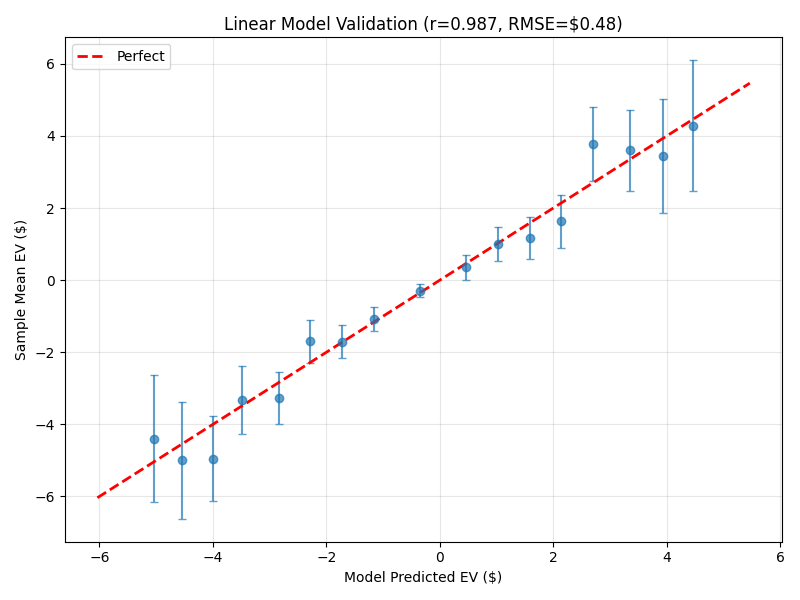

In [55]:
# Validation: Compare model predictions with sample means by TC
df["predicted_ev"] = model.predict(X_with_const)

validation_by_tc = df.groupby("tc").agg({
    "ev": ["mean", "std", "count"],
    "predicted_ev": "mean"
})
validation_by_tc.columns = ["actual_mean", "std", "n", "predicted_mean"]
validation_by_tc["se"] = validation_by_tc["std"] / np.sqrt(validation_by_tc["n"])
validation_by_tc = validation_by_tc[validation_by_tc["n"] >= 100]  # filter sparse TCs

# Compute correlation between predicted and actual means
corr = np.corrcoef(validation_by_tc["predicted_mean"], validation_by_tc["actual_mean"])[0, 1]
rmse = np.sqrt(((validation_by_tc["predicted_mean"] - validation_by_tc["actual_mean"])**2).mean())

print("Validation: Model Predictions vs Sample Means by True Count")
print("="*60)
print(f"Correlation: {corr:.4f}")
print(f"RMSE: ${rmse:.4f}")
print(f"\nNote: If correlation ≈ 1 and RMSE is small, linear model is valid baseline")

f, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(validation_by_tc["predicted_mean"], validation_by_tc["actual_mean"], 
            yerr=1.96*validation_by_tc["se"], fmt='o', capsize=3, alpha=0.7)
lims = [validation_by_tc["predicted_mean"].min()-1, validation_by_tc["predicted_mean"].max()+1]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
ax.set_xlabel("Model Predicted EV ($)")
ax.set_ylabel("Sample Mean EV ($)")
ax.set_title(f"Linear Model Validation (r={corr:.3f}, RMSE=${rmse:.2f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [56]:
# Summary: Using the linear model as baseline
print("="*70)
print("HOW TO USE THIS MODEL AS BASELINE FOR C++ SOLVER COMPARISON")
print("="*70)

print("""
1. THE MODEL:
   EV($100) = intercept + Σ coef_i × (n_i / total_cards)
   
   Coefficients saved to: hilo_linear_model_coefficients.csv

2. TO PREDICT EXPECTED EV FOR ANY SHOE:
   Use predict_hilo_ev() function or load coefficients:
   
   coefs = pd.read_csv("hilo_linear_model_coefficients.csv")
   # coefs["coefficient"] contains [intercept, coef_2, ..., coef_A]

3. TO COMPARE WITH C++ SOLVER:
   For each shoe state:
   - Compute HiLo expected EV using this linear model
   - Compute C++ solver EV
   - Compare: solver_ev - hilo_ev = edge gained from perfect play

4. MODEL VALIDITY:
   - Fitted on ~1M simulated rounds
   - Coefficients have small standard errors (see table above)
   - Validated against sample means by true count
   
5. LIMITATIONS:
   - Linear approximation (no interactions between cards)
   - Based on HiLo DEVIATED strategy, not basic strategy
   - For $100 bet unit; scale linearly for other bet sizes
""")

print("\nCoefficients summary:")
print(coef_df[["card", "coefficient", "std_err"]].to_string(index=False))


HOW TO USE THIS MODEL AS BASELINE FOR C++ SOLVER COMPARISON

1. THE MODEL:
   EV($100) = intercept + Σ coef_i × (n_i / total_cards)

   Coefficients saved to: hilo_linear_model_coefficients.csv

2. TO PREDICT EXPECTED EV FOR ANY SHOE:
   Use predict_hilo_ev() function or load coefficients:

   coefs = pd.read_csv("hilo_linear_model_coefficients.csv")
   # coefs["coefficient"] contains [intercept, coef_2, ..., coef_A]

3. TO COMPARE WITH C++ SOLVER:
   For each shoe state:
   - Compute HiLo expected EV using this linear model
   - Compute C++ solver EV
   - Compare: solver_ev - hilo_ev = edge gained from perfect play

4. MODEL VALIDITY:
   - Fitted on ~1M simulated rounds
   - Coefficients have small standard errors (see table above)
   - Validated against sample means by true count

5. LIMITATIONS:
   - Linear approximation (no interactions between cards)
   - Based on HiLo DEVIATED strategy, not basic strategy
   - For $100 bet unit; scale linearly for other bet sizes


Coefficients s

## Fit and Save EVEstimator Models

Fit linear models on both proportions and raw counts, save as EVEstimator objects.


In [57]:
len(df["ev"])

37237

In [58]:
import sys
sys.path.insert(0, "..")
from blackjack.ev_estimator import EVEstimator, CardProportionTransformer
import pickle
import os

# Create output directory
os.makedirs("../sklearn_models", exist_ok=True)

# Prepare data: raw card counts
X_counts = df[card_columns].values  # [n2, n3, ..., n10, nA]
y = df["ev"].values

print(f"Training data: {len(y):,} samples")
print(f"Features: {card_columns}")

# Model 1: Linear on proportions only
estimator_prop = EVEstimator(degree=1, keep_total_count=False, keep_individual_counts=False)
estimator_prop.fit(X_counts, y)

print(f"\n1. EVEstimator (proportions only, degree=1):")
print(f"   R² (train): {estimator_prop.r2_train:.6f}")
print(f"   {estimator_prop}")

# Model 2: Linear on proportions + individual counts
estimator_prop_counts = EVEstimator(degree=1, keep_total_count=False, keep_individual_counts=True)
estimator_prop_counts.fit(X_counts, y)

print(f"\n2. EVEstimator (proportions + counts, degree=1):")
print(f"   R² (train): {estimator_prop_counts.r2_train:.6f}")
print(f"   {estimator_prop_counts}")


Training data: 37,237 samples
Features: ['n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'nA']

1. EVEstimator (proportions only, degree=1):
   R² (train): 0.020044
   EVEstimator(degree=1, fitted, R²=0.0200)

2. EVEstimator (proportions + counts, degree=1):
   R² (train): 0.020321
   EVEstimator(degree=1, fitted, R²=0.0203)


MODEL COEFFICIENTS COMPARISON

1. PROPORTIONS ONLY (10 features): EV = intercept + Σ coef_i × p_i
   Intercept: -8.8067
   p_ 2: -14.7878
   p_ 3: -21.1282
   p_ 4: -23.8766
   p_ 5: -33.9501
   p_ 6: -10.0835
   p_ 7: -12.1225
   p_ 8: +12.9479
   p_ 9: +25.6139
   p_10: +36.6604
   p_ A: +40.7265

2. PROPORTIONS + COUNTS (20 features):
   Intercept: -9.1924
   Proportion coefficients:
   p_ 2: -30.1457
   p_ 3: -29.1857
   p_ 4: -22.5966
   p_ 5: -30.7533
   p_ 6: -10.6077
   p_ 7: -7.1697
   p_ 8: +10.7036
   p_ 9: +35.5687
   p_10: +37.4992
   p_ A: +46.6872
   Count coefficients:
   n_ 2: +0.137194
   n_ 3: +0.073759
   n_ 4: -0.008622
   n_ 5: -0.025622
   n_ 6: +0.008841
   n_ 7: -0.043360
   n_ 8: +0.018877
   n_ 9: -0.085972
   n_10: -0.003237
   n_ A: -0.049069


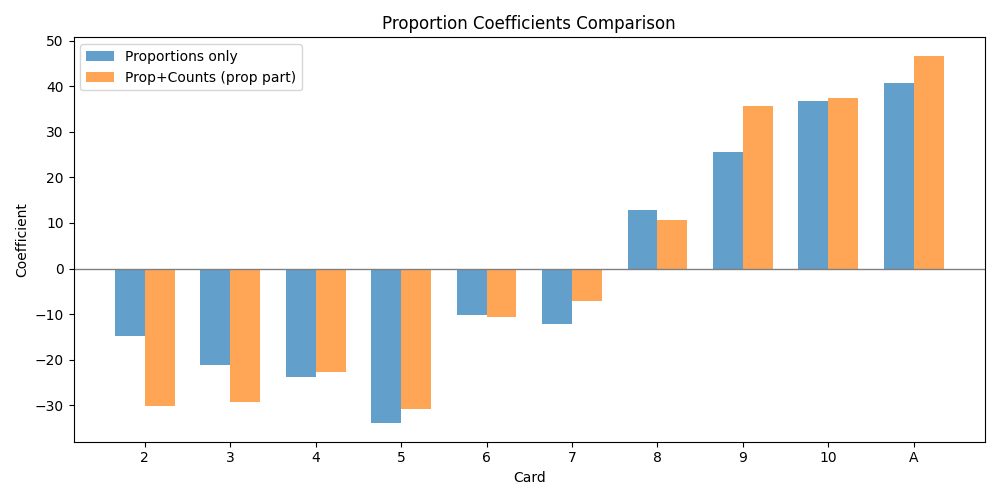

In [59]:
# Extract and compare coefficients
card_names = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]

# Model 1: Proportions only (10 features)
reg_prop = estimator_prop.pipeline.named_steps['linearregression']
coef_prop = reg_prop.coef_
intercept_prop = reg_prop.intercept_

# Model 2: Proportions + counts (20 features)
reg_prop_counts = estimator_prop_counts.pipeline.named_steps['linearregression']
coef_prop_counts = reg_prop_counts.coef_
intercept_prop_counts = reg_prop_counts.intercept_

print("="*70)
print("MODEL COEFFICIENTS COMPARISON")
print("="*70)

print("\n1. PROPORTIONS ONLY (10 features): EV = intercept + Σ coef_i × p_i")
print(f"   Intercept: {intercept_prop:.4f}")
for name, coef in zip(card_names, coef_prop):
    print(f"   p_{name:>2}: {coef:+.4f}")

print("\n2. PROPORTIONS + COUNTS (20 features):")
print(f"   Intercept: {intercept_prop_counts:.4f}")
print("   Proportion coefficients:")
for name, coef in zip(card_names, coef_prop_counts[:10]):
    print(f"   p_{name:>2}: {coef:+.4f}")
print("   Count coefficients:")
for name, coef in zip(card_names, coef_prop_counts[10:]):
    print(f"   n_{name:>2}: {coef:+.6f}")

# Visualize proportion coefficients comparison
f, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(card_names))
width = 0.35

bars1 = ax.bar(x - width/2, coef_prop, width, label='Proportions only', alpha=0.7)
bars2 = ax.bar(x + width/2, coef_prop_counts[:10], width, label='Prop+Counts (prop part)', alpha=0.7)

ax.axhline(0, color='grey', lw=1)
ax.set_xlabel("Card")
ax.set_ylabel("Coefficient")
ax.set_title("Proportion Coefficients Comparison")
ax.set_xticks(x)
ax.set_xticklabels(card_names)
ax.legend()

plt.tight_layout()
plt.show()


In [60]:
# Save both estimators to pickle files in ../sklearn_models/
save_dir = "../sklearn_models"

with open(f"{save_dir}/hilo_ev_proportions.pkl", "wb") as f:
    pickle.dump(estimator_prop, f)
print(f"Saved: {save_dir}/hilo_ev_proportions.pkl")

with open(f"{save_dir}/hilo_ev_proportions_counts.pkl", "wb") as f:
    pickle.dump(estimator_prop_counts, f)
print(f"Saved: {save_dir}/hilo_ev_proportions_counts.pkl")

print("\n" + "="*70)
print("USAGE")
print("="*70)
print("""
# Load and use the proportions-only model:
with open("sklearn_models/hilo_ev_proportions.pkl", "rb") as f:
    model = pickle.load(f)

# Predict EV for a shoe state (raw counts as input)
shoe_counts = [24, 24, 24, 24, 24, 24, 24, 24, 96, 24]  # fresh 6-deck [n2..n10, nA]
ev = model.predict([shoe_counts])

# Load and use the proportions+counts model:
with open("sklearn_models/hilo_ev_proportions_counts.pkl", "rb") as f:
    model = pickle.load(f)
ev = model.predict([shoe_counts])
""")


Saved: ../sklearn_models/hilo_ev_proportions.pkl
Saved: ../sklearn_models/hilo_ev_proportions_counts.pkl

USAGE

# Load and use the proportions-only model:
with open("sklearn_models/hilo_ev_proportions.pkl", "rb") as f:
    model = pickle.load(f)

# Predict EV for a shoe state (raw counts as input)
shoe_counts = [24, 24, 24, 24, 24, 24, 24, 24, 96, 24]  # fresh 6-deck [n2..n10, nA]
ev = model.predict([shoe_counts])

# Load and use the proportions+counts model:
with open("sklearn_models/hilo_ev_proportions_counts.pkl", "rb") as f:
    model = pickle.load(f)
ev = model.predict([shoe_counts])



In [61]:
# Verify models work correctly
print("="*70)
print("MODEL VERIFICATION")
print("="*70)

# Test cases
test_shoes = {
    "Fresh 6-deck": [24, 24, 24, 24, 24, 24, 24, 24, 96, 24],
    "Missing 4 tens": [24, 24, 24, 24, 24, 24, 24, 24, 92, 24],
    "Missing 4 fives": [24, 24, 24, 20, 24, 24, 24, 24, 96, 24],
    "High count (rich in 10s)": [20, 20, 20, 20, 20, 24, 24, 24, 100, 28],
    "Low count (poor in 10s)": [28, 28, 28, 28, 28, 24, 24, 24, 88, 20],
}

print(f"\n{'Shoe State':<25} {'Prop Only':>15} {'Prop+Counts':>15}")
print("-"*55)
for name, counts in test_shoes.items():
    ev_prop = estimator_prop.predict([counts])[0]
    ev_prop_counts = estimator_prop_counts.predict([counts])[0]
    print(f"{name:<25} ${ev_prop:>14.4f} ${ev_prop_counts:>14.4f}")

# Compare with sample mean
print("\n" + "="*70)
print("COMPARISON WITH SAMPLE DATA")
print("="*70)
print(f"\nOverall sample mean EV: ${df['ev'].mean():.4f}")
print(f"Proportions only model mean: ${estimator_prop.predict(X_counts).mean():.4f}")
print(f"Prop+Counts model mean: ${estimator_prop_counts.predict(X_counts).mean():.4f}")


MODEL VERIFICATION

Shoe State                      Prop Only     Prop+Counts
-------------------------------------------------------
Fresh 6-deck              $       -0.3466 $       -0.2249
Missing 4 tens            $       -0.7129 $       -0.5865
Missing 4 fives           $        0.2042 $        0.3894
High count (rich in 10s)  $        2.4080 $        1.9362
Low count (poor in 10s)   $       -3.2815 $       -2.5390

COMPARISON WITH SAMPLE DATA

Overall sample mean EV: $-0.3760
Proportions only model mean: $-0.3760
Prop+Counts model mean: $-0.3760
